# Problem interpolation CloudSEN12 models

```
pip install georeader-spaceml cloudsen12_models earthengine-api matplotlib numpy
```
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IPL-UV/cloudsen12_models/blob/main/notebooks/problem_interp_cloudsen12.ipynb)

In [1]:
from cloudsen12_models import cloudsen12
import ee
import matplotlib.pyplot as plt
from georeader import plot
from shapely.geometry import box
from georeader.readers import ee_image

/home/gonzalo/mambaforge/envs/marsmlpy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ee.Authenticate()
ee.Initialize()

In [3]:
# long/lat: 49.25803 , 24.87275 
# S2A_MSIL1C_20250111T072251_N0511_R006_T39RUH_20250111T075809
collection_name = "COPERNICUS/S2_HARMONIZED"
tile = "S2A_MSIL1C_20250111T072251_N0511_R006_T39RUH_20250111T075809"
img_col = ee.ImageCollection(collection_name)
image = img_col.filter(ee.Filter.eq("PRODUCT_ID", tile)).first()
info_img = image.getInfo()
# info_img

In [4]:
%%time

# from marsml.geospatial import center_polygon_meters
from rasterio import Affine
from shapely.geometry import mapping, shape
from georeader.readers import S2_SAFE_reader
# projgee = image.select("B2").projection().getInfo()

# long/lat: 49.25803 , 24.87275 
# aoi = center_polygon_meters(49.25803 , 24.87275, margin_meters=2_000)
# aoi = box(55.325, 25.225, 55.415, 25.28)

aoi = shape({'type': 'Polygon',
 'coordinates': (((49.26659036683836, 24.86598286772722),
   (49.26633841678161, 24.884037050758284),
   (49.246546491004146, 24.883805801163398),
   (49.24680131381584, 24.8657518082537),
   (49.26659036683836, 24.86598286772722)),)})

channels_query_original = S2_SAFE_reader.BANDS_S2_L1C
bands = [b.replace("B0","B") for b in channels_query_original]
crs = info_img["bands"][1]["crs"]
transform = Affine(*info_img["bands"][1]["crs_transform"])
img_local = ee_image.export_image(info_img['id'],
                                  crs=crs, transform=transform,
                                  bands_gee=bands,
                                  geometry=aoi)
img_local

CPU times: user 103 ms, sys: 28.2 ms, total: 131 ms
Wall time: 1.13 s


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


 
         Transform: | 10.00, 0.00, 322870.00|
| 0.00,-10.00, 2753230.00|
| 0.00, 0.00, 1.00|
         Shape: (13, 202, 202)
         Resolution: (10.0, 10.0)
         Bounds: (322870.0, 2751210.0, 324890.0, 2753230.0)
         CRS: EPSG:32639
         fill_value_default: 0.0
        

<Axes: >

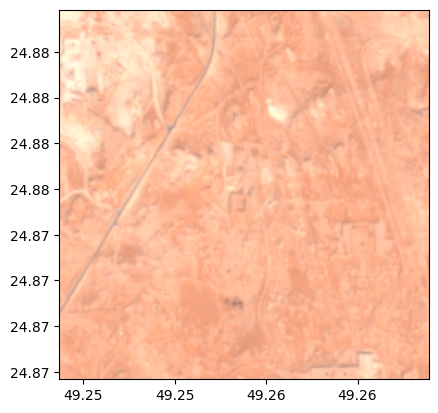

In [5]:
rgb = (img_local.isel({"band": [bands.index(b) for b in ["B4","B3","B2"]]}) / 4_500.).clip(0,1)
# swirnirred = (img_local.isel({"band": [bands.index(b) for b in ["B11","B8","B4"]]}) / 7_500.).clip(0,1)

plot.show(rgb)

<Axes: >

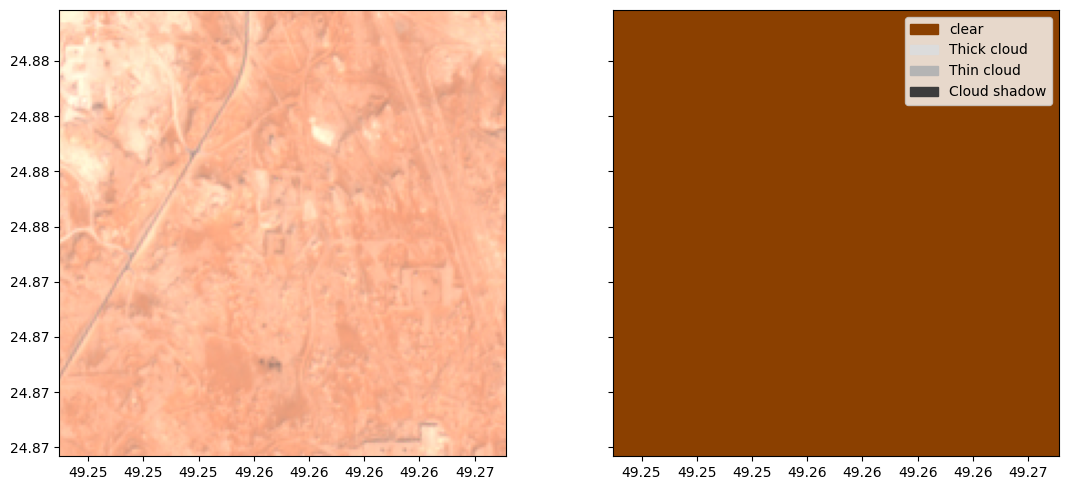

In [6]:
modelv2 = cloudsen12.load_model_by_name(name="UNetMobV2_V2", weights_folder="cloudsen12_models")
cloudmaskv2 = modelv2.predict(img_local/10_000)
fig, ax = plt.subplots(1,2,figsize=(14,5),sharey=True, tight_layout=True)

plot.show(rgb,ax=ax[0])
cloudsen12.plot_cloudSEN12mask(cloudmaskv2,ax=ax[1])

In [7]:
from georeader.geotensor import GeoTensor
from typing import List, Optional
from georeader.readers import S2_SAFE_reader

def find_padding(v:int, divisor:int=8):
    v_divisible = max(divisor, int(divisor * np.ceil(v / divisor)))
    total_pad = v_divisible - v
    pad_1 = total_pad // 2
    pad_2 = total_pad - pad_1
    return pad_1, pad_2
    
def interpolate_20mbands_s2ee(geotensor:GeoTensor, 
                              channels_query_original:Optional[List[str]]=None, 
                              inplace:bool=True) -> GeoTensor:
    """
    Interpolates 20m bands of Sentinel-2 to 10m using bilinear interpolation.
    Input is intended to be a S2 image downloaded from Google Earth Engine.

    Args:
        geotensor (GeoTensor): GeoTensor object with S2 image in np.uint16 multiplied by 10_000
        channels_query_original (Optional[List[str]], optional): list of channels to interpolate. 
            Defaults to None. They must be in S2_SAFE_reader.BANDS_S2_L1C
        inplace (bool, optional): whether to modify the input GeoTensor. Defaults to True.

    Returns:
        GeoTensor: GeoTensor object with 20m bands interpolated to 10m
    """
    assert geotensor.dtype == np.uint16, f"Expected np.uint16, found {geotensor.dtype}"

    if channels_query_original is None:
        channels_query_original = S2_SAFE_reader.BANDS_S2_L1C
    else:
        # Check all channels in S2_SAFE_reader.BANDS_S2_L1C
        for b in channels_query_original:
            assert b in S2_SAFE_reader.BANDS_S2_L1C, f"S2 Channel {b} not found in {S2_SAFE_reader.BANDS_S2_L1C}"
    
    indexes_20m = [i for i, c in enumerate(channels_query_original) if c in S2_SAFE_reader.BANDS_RESOLUTION and S2_SAFE_reader.BANDS_RESOLUTION[c] == 20]

    if not inplace:
        geotensor = geotensor.copy()
    
    # Reproject 20m bands to 10m
    # Pad if the shape is not divisible by 2 and use GeoTensor.resize
    b20ms2:GeoTensor = geotensor.isel({"band": indexes_20m}).astype(np.float64) / 10_000
    pad_r = find_padding(b20ms2.shape[-2], divisor=2)
    pad_c = find_padding(b20ms2.shape[-1], divisor=2)
    need_pad = any([p > 0 for p in pad_r + pad_r])
    if need_pad:
        # edge: Pads with the edge values of array.
        b20ms2 = b20ms2.pad({"x": pad_c, "y": pad_r}, mode="edge")
    
    output_shape_20m = b20ms2.shape[-2] // 2, b20ms2.shape[-1] // 2
    
    b20ms2_20m:GeoTensor = b20ms2.resize(output_shape_20m, anti_aliasing=False,
                                         interpolation="nearest")
    b20ms2_20m10m:GeoTensor = b20ms2_20m.resize(b20ms2.shape[-2:],
                                                anti_aliasing=False, interpolation="bilinear")
    if need_pad:
        slice_rows = slice(pad_r[0], None if pad_r[1] <= 0 else -pad_r[1])
        slice_cols = slice(pad_c[0], None if pad_c[1] <= 0 else -pad_c[1])
        b20ms2_20m10m.values = b20ms2_20m10m.values[(slice(None), slice_rows, slice_cols)]
    
    geotensor.values[indexes_20m,...] = np.round(b20ms2_20m10m.values * 10_000).astype(np.uint16)

    return geotensor

def assess_difs(image, image2):
    diffbands = []
    for b in range(image2.shape[0]):
        band_eq = (image2.values[b] == image.values[b]).all()
        if not band_eq:
            diffbands.append(b)
        print(f"Band {channels_query_original[b]} is equal {band_eq}")
    
    nrows = 2
    ncols = len(diffbands) // 2
    fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), sharex=True, sharey=True, tight_layout=True)
    ax = ax.flatten()
    diff = image2.astype(np.float64) - image.astype(np.float64)
    for i, b in enumerate(diffbands):
        plot.show(diff.isel({"band": b}), add_colorbar_next_to=True, ax=ax[i], title=f"{channels_query_original[b]}")

## Original code

<Axes: >

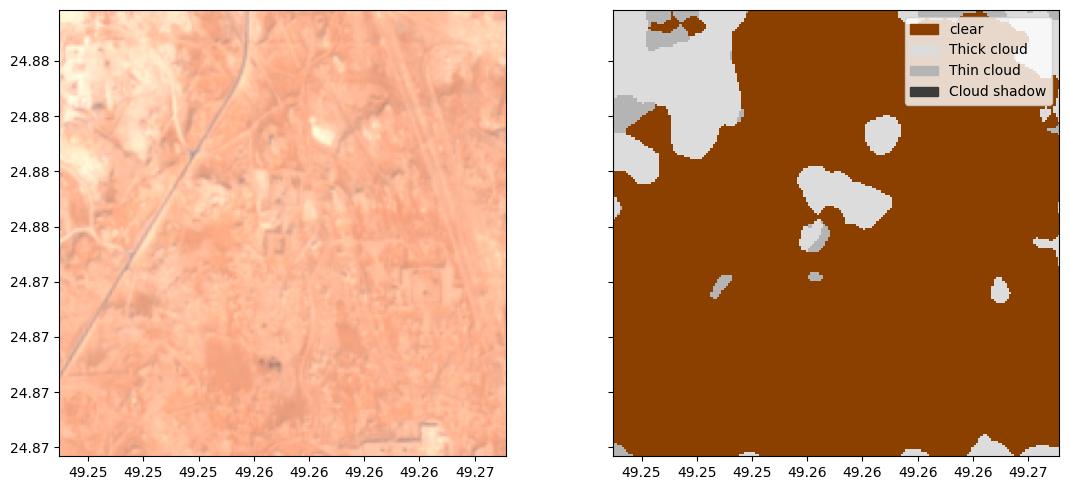

In [8]:
import numpy as np

invalids = ~np.all(np.isfinite(img_local.values), axis=0)
if img_local.fill_value_default is not None:
    invalids |= np.any(img_local.values == img_local.fill_value_default, axis=0)

img_local_interp = interpolate_20mbands_s2ee(img_local, channels_query_original=channels_query_original,
                                             inplace=False)
img_local_interp.values[:, invalids] = img_local_interp.fill_value_default

rgb2 = (img_local_interp.isel({"band": [bands.index(b) for b in ["B4","B3","B2"]]}) / 4_500.).clip(0,1)

cloudmaskv2_interp = modelv2.predict(img_local_interp/10_000)
fig, ax = plt.subplots(1,2,figsize=(14,5),sharey=True, tight_layout=True)

plot.show(rgb2,ax=ax[0])
cloudsen12.plot_cloudSEN12mask(cloudmaskv2_interp, ax=ax[1])

In [9]:
invalids.any()

False

Band B01 is equal True
Band B02 is equal True
Band B03 is equal True
Band B04 is equal True
Band B05 is equal False
Band B06 is equal False
Band B07 is equal False
Band B08 is equal True
Band B8A is equal False
Band B09 is equal True
Band B10 is equal True
Band B11 is equal False
Band B12 is equal False


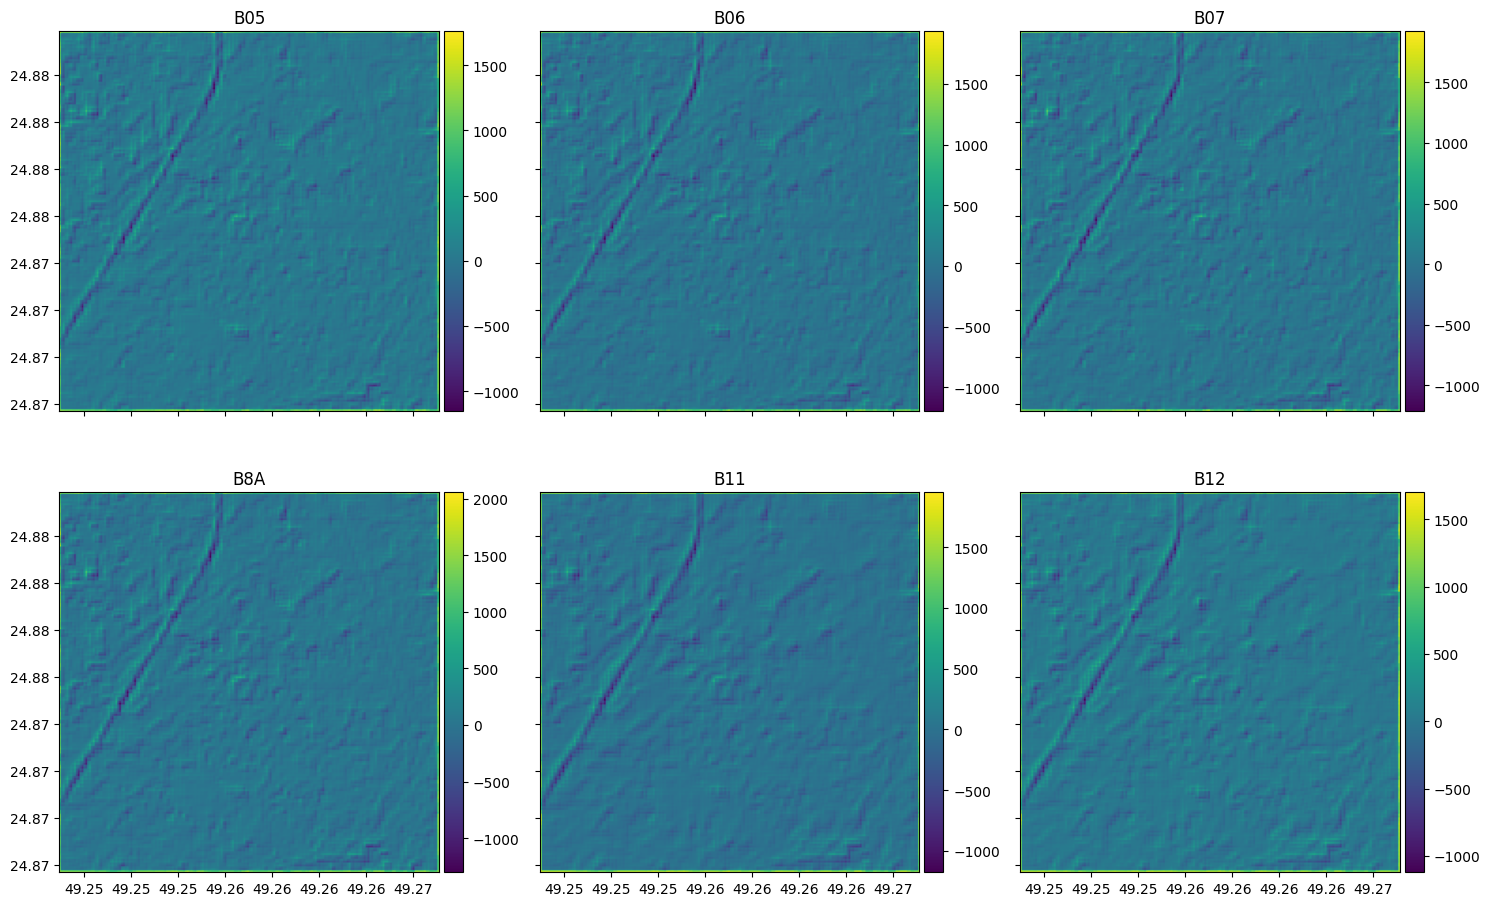

In [10]:
# img_local - img_local_interp
assess_difs(img_local_interp, img_local)